In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# =====================================================
# Load Dataset & Basic Preprocessing
# =====================================================

df = pd.read_csv('../Data/uber_taxi_demand_5years.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)   

In [3]:
zone_demand = (df.groupby('zone')['pickup_count'].sum().sort_values(ascending=False))
print(zone_demand)

zone
Midtown     2708473
Airport     2399322
Downtown    2160030
Uptown      1025075
Suburb       337696
Name: pickup_count, dtype: int64


In [4]:
print("Top Zone:", zone_demand.idxmax())
print("Total Pickups:", zone_demand.max(),"\n")

print("Lowest Demand Zone:", zone_demand.idxmin())
print("Total Pickups:", zone_demand.min())

Top Zone: Midtown
Total Pickups: 2708473 

Lowest Demand Zone: Suburb
Total Pickups: 337696


In [5]:
holiday_effect = df.groupby("is_holiday")["pickup_count"].mean()
print("Normal Day Average :", round(holiday_effect[0], 2))
print("Holiday Average    :", round(holiday_effect[1], 2))

Normal Day Average : 39.32
Holiday Average    : 44.35


In [6]:
rain_effect = df.groupby("is_raining")["pickup_count"].mean()

print("No Rain Average :", round(rain_effect[0], 2))
print("Rain Average    :", round(rain_effect[1], 2))

No Rain Average : 36.94
Rain Average    : 52.2


In [7]:
holiday_change = (
    (holiday_effect[1] - holiday_effect[0])
    / holiday_effect[0]
) * 100

rain_change = (
    (rain_effect[1] - rain_effect[0])
    / rain_effect[0]
) * 100

print(f"Holiday effect : {holiday_change:.2f}%")
print(f"Rain effect    : {rain_change:.2f}%")

Holiday effect : 12.81%
Rain effect    : 41.31%


In [8]:
holiday_rain = df.groupby(
    ["is_holiday", "is_raining"]
)["pickup_count"].mean().reset_index()

print(holiday_rain)

   is_holiday  is_raining  pickup_count
0           0           0     36.901382
1           0           1     52.043652
2           1           0     40.006737
3           1           1     60.872000


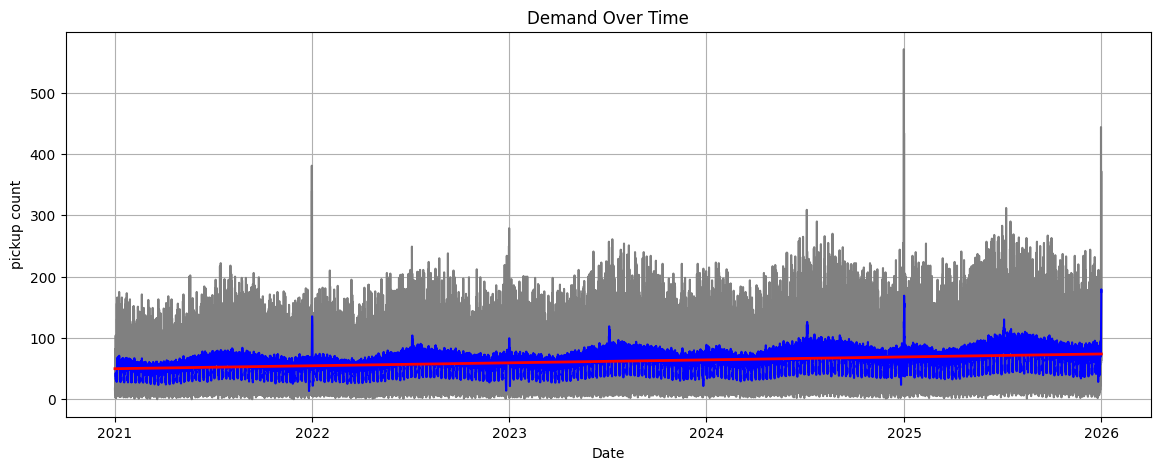

Slope: 0.0005


In [9]:
# Demand Over Time For Select Zone (line plot - full 5 years):
n = 'Midtown'
zone_df = df[df['zone'] == n].copy()

x = np.arange(len(zone_df))
y = zone_df['pickup_count'].values
coeffs = np.polyfit(x, y, deg=1)
trend_line = np.polyval(coeffs, x)

zone_df['SMA_7'] = zone_df['pickup_count'].rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(zone_df.index, zone_df['pickup_count'], color='grey')
plt.plot(zone_df['SMA_7'], label='SMA 7-day', color='blue')
plt.plot(zone_df.index, trend_line, label='Trend Line (deg=1)', 
         color='red', linewidth=2)

plt.title("Demand Over Time")
plt.xlabel("Date")
plt.ylabel("pickup count")
plt.grid()
plt.show()

print(f"Slope: {coeffs[0]:.4f}")

D:\Temp\ipykernel_4416\582023942.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zone_df, x='hour', y='pickup_count', errorbar=None, palette='viridis', legend=False)


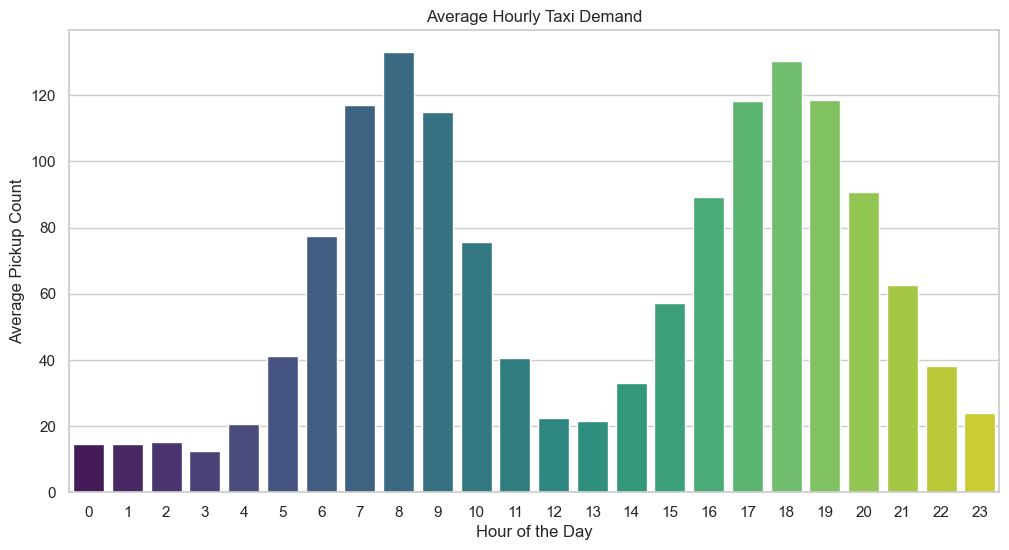

In [10]:
n = 'Midtown'
zone_df = df[df['zone'] == n].copy()

zone_df['hour'] = zone_df.index.hour

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(data=zone_df, x='hour', y='pickup_count', errorbar=None, palette='viridis', legend=False)
plt.title('Average Hourly Taxi Demand')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Pickup Count')
plt.xticks(range(24))

plt.show()

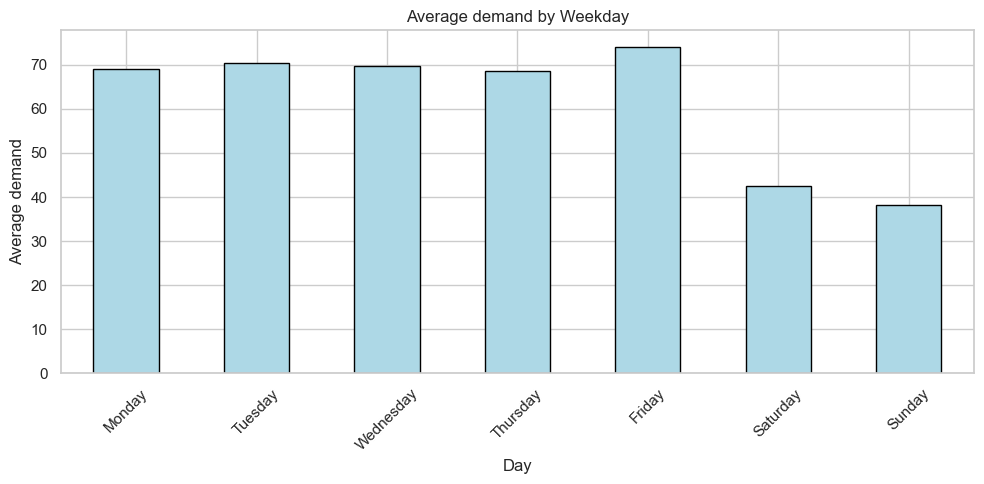

weekday
Monday       69.118774
Tuesday      70.372605
Wednesday    69.673372
Thursday     68.642468
Friday       74.091475
Saturday     42.607280
Sunday       38.144157
Name: pickup_count, dtype: float64


In [11]:
n = 'Midtown'
zone_df = df[df['zone'] == n].copy()
zone_df['weekday'] = zone_df.index.day_name()

weekday_order = ['Monday','Tuesday','Wednesday',
                 'Thursday','Friday','Saturday','Sunday']

weekday_avg = zone_df.groupby('weekday')['pickup_count'].mean()
weekday_avg = weekday_avg.reindex(weekday_order)

# Plot
plt.figure(figsize=(10,5))
weekday_avg.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Average demand by Weekday')
plt.xlabel('Day')
plt.ylabel('Average demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(weekday_avg)

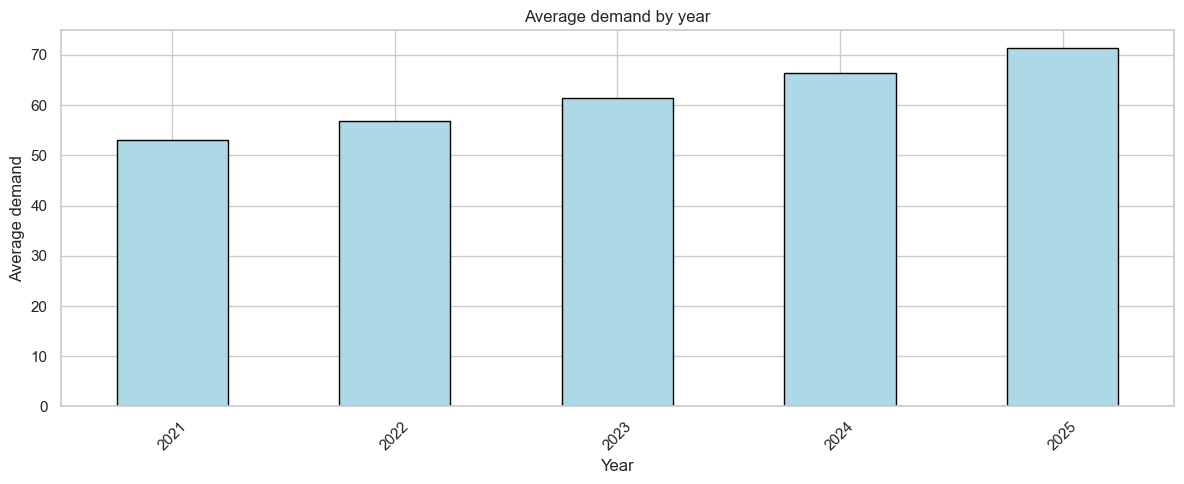

year
2021    53.023973
2022    56.907534
2023    61.311872
2024    66.449112
2025    71.311872
Name: pickup_count, dtype: float64


In [12]:
n = 'Midtown'
zone_df = df[df['zone'] == n].copy()
zone_df['year'] = zone_df.index.year

year = zone_df.groupby('year')['pickup_count'].mean()

plt.figure(figsize=(12,5))
year.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Average demand by year')
plt.xlabel('Year')
plt.ylabel('Average demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(year)

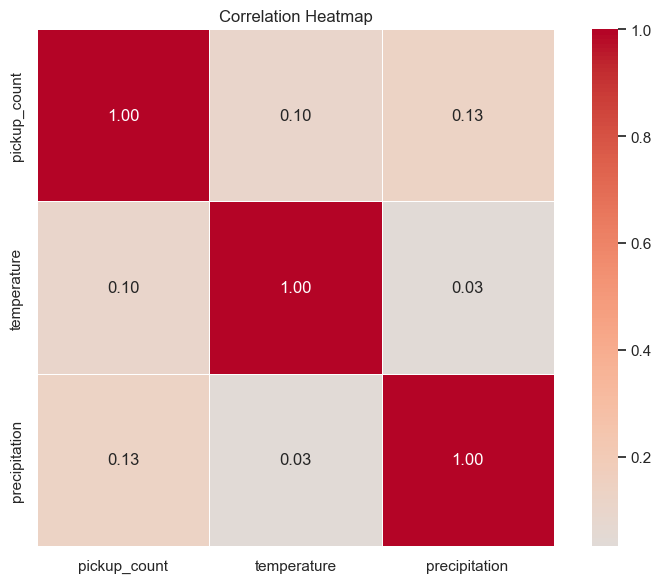

               pickup_count  temperature  precipitation
pickup_count       1.000000      0.09988       0.129194
temperature        0.099880      1.00000       0.033130
precipitation      0.129194      0.03313       1.000000


In [13]:
# Correlation Heatmap
corr = df[["pickup_count","temperature","precipitation"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0,linewidths=0.5,square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print(corr)